# Cross-Application Analysis: Library Calls, Power, and Energy

Comparative analysis of GPU compute library calls across multiple HPC
application traces, using ampere's exclusive attribution engine to
correctly attribute energy and power to the deepest active function
(no double-counting of wrapper overhead).

All GPU-idle artefacts (MPI communication, application framework
orchestration) are excluded — these are inflated by the synchronous
instrumentation that inserts device syncs to enable per-call attribution.

In [13]:
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import seaborn as sns
import arkouda as ak
from ampere import Ensemble, MetricConfig, MetricType, connect

plt.rcParams.update({
    'figure.dpi': 180,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 9.5,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
    'figure.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.0,
})
BG = '#fafafa'

connect(server="localhost", port=5555)

/Users/hom/miniconda3/envs/ampere_dev/lib/python3.11/site-packages/arkouda/core/client.py:860: RuntimeWarning: Version mismatch between client (2026.02.02+40.gec39a6ec8) and server (2026.02.02.1); this may cause some commands to fail or behave incorrectly! Updating arkouda is strongly recommended.
  warnings.warn(
connected to arkouda server tcp://*:5555


Connecting to Arkouda server at localhost:5555...


In [14]:
# -- Load all traces through ampere's attribution engine --

configs = {
    re.compile(r".*energy_count.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}

def topo_resolver(metric_name, ranks):
    if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
    if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
    if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
    if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
    return ranks

devices = [
    "A2rocm_smi:::energy_count:device=0",
    "A2rocm_smi:::energy_count:device=2",
    "A2rocm_smi:::energy_count:device=4",
    "A2rocm_smi:::energy_count:device=6",
]

ranks = [f"MPI Rank {i}" for i in range(8)]
node_ranks = {"Node0": ranks}

TRACES = {
    'HPL':     './hpl-captured-params',
    'HPG-MxP': './hpg-mxp-2',
    'HPL-MxP': './hpl-mxp',
}

# Attribute energy + power for each application
app_frames = {}
for app_name, path in TRACES.items():
    print(f"\n{'='*50}")
    print(f"Loading {app_name} from {path}")
    ens = Ensemble.from_trace_paths([path], node_ranks, configs)

    joules = ak.DataFrame.concat([
        ens.attribute(m, topology_resolver=topo_resolver, strategy='exclusive')
        for m in devices
    ]).to_pandas()

    power = ak.DataFrame.concat([
        ens.attribute(m, topology_resolver=topo_resolver, strategy='exclusive', output_mode='rate')
        for m in devices
    ]).to_pandas()

    joules['Duration'] = joules['End Time'] - joules['Start Time']
    power['Duration']  = power['End Time']  - power['Start Time']
    joules['App'] = app_name
    power['App']  = app_name

    app_frames[app_name] = {'energy': joules, 'power': power}

energy_all = pd.concat([v['energy'] for v in app_frames.values()], ignore_index=True)
power_all  = pd.concat([v['power']  for v in app_frames.values()], ignore_index=True)

print(f"\nTotal attributed calls: {len(energy_all):,}")


Loading HPL from ./hpl-captured-params


Loading Runs: 100%|██████████| 1/1 [00:20<00:00, 20.06s/it]


Attributing 'A2rocm_smi:::energy_count:device=0' on Arkouda Server...


100%|██████████| 1/1 [00:03<00:00,  3.85s/it]


Attributing 'A2rocm_smi:::energy_count:device=2' on Arkouda Server...


...

Attributing 'A2rocm_smi:::energy_count:device=4' on Arkouda Server...


100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


Attributing 'A2rocm_smi:::energy_count:device=6' on Arkouda Server...


100%|██████████| 1/1 [00:00<00:00,  1.05it/s]


This transfer will use 69 MB .
Total attributed calls: 24,571,301


In [15]:
# -- Classification: only care about compute libraries --

def classify(name):
    n = name.lower()
    if n.startswith('mpi_'):           return '_idle'
    if 'rocblas' in n:                 return 'rocBLAS'
    if 'rocsolver' in n:              return 'rocSOLVER'
    if (n.startswith('hip') or 'devicemalloc' in n
        or 'hostmalloc' in n):         return 'HIP Runtime'
    if n.startswith('hpl_') or n.startswith('hplmxp') or n == 'main':
        return '_idle'
    return 'Other'

def short_name(name):
    paren = name.find('(')
    base = name[:paren] if paren != -1 else name
    angle = base.find('<')
    if angle != -1:
        base = base[:angle]
    return base.strip()

for df in (energy_all, power_all):
    df['Library']   = df['Name'].apply(classify)
    df['ShortName'] = df['Name'].apply(short_name)

# Keep only compute library calls
energy = energy_all[energy_all['Library'] != '_idle'].copy()
power  = power_all[power_all['Library']  != '_idle'].copy()

# Significant calls (>= 1 ms duration)
MIN_DUR = 1e-3
energy_sig = energy[energy['Duration'] >= MIN_DUR].copy()
power_sig  = power[power['Duration']   >= MIN_DUR].copy()

CAT_PALETTE = {
    'rocBLAS':     '#2d6a4f',
    'rocSOLVER':   '#e07a3a',
    'HIP Runtime': '#9b5de5',
    'Other':       '#457b9d',
}
CAT_ORDER = ['rocBLAS', 'rocSOLVER', 'HIP Runtime', 'Other']

APP_PALETTE = {app: c for app, c in zip(
    TRACES.keys(), ['#e07a3a', '#2d6a4f', '#9b5de5', '#457b9d'])}

print("Compute-library energy by (app, library):")
print(energy.groupby(['App', 'Library'])['Value'].sum()
      .unstack(fill_value=0).to_string())
print(f"\nSignificant compute calls: {len(energy_sig):,}")

Compute-library energy by (app, library):
Library  HIP Runtime         Other        rocBLAS
App                                              
HPG-MxP     0.000000  46368.374433    9890.870324
HPL         1.579618      0.000000  124792.327639
HPL-MxP     0.000000     67.294204   15300.654423

Significant compute calls: 158,396


## Figure 1 -- Energy Composition by Application

For each application, the share of GPU energy consumed by each compute library.
Uses exclusive attribution, so energy is assigned only to the deepest active
function — no double-counting of wrapper calls.

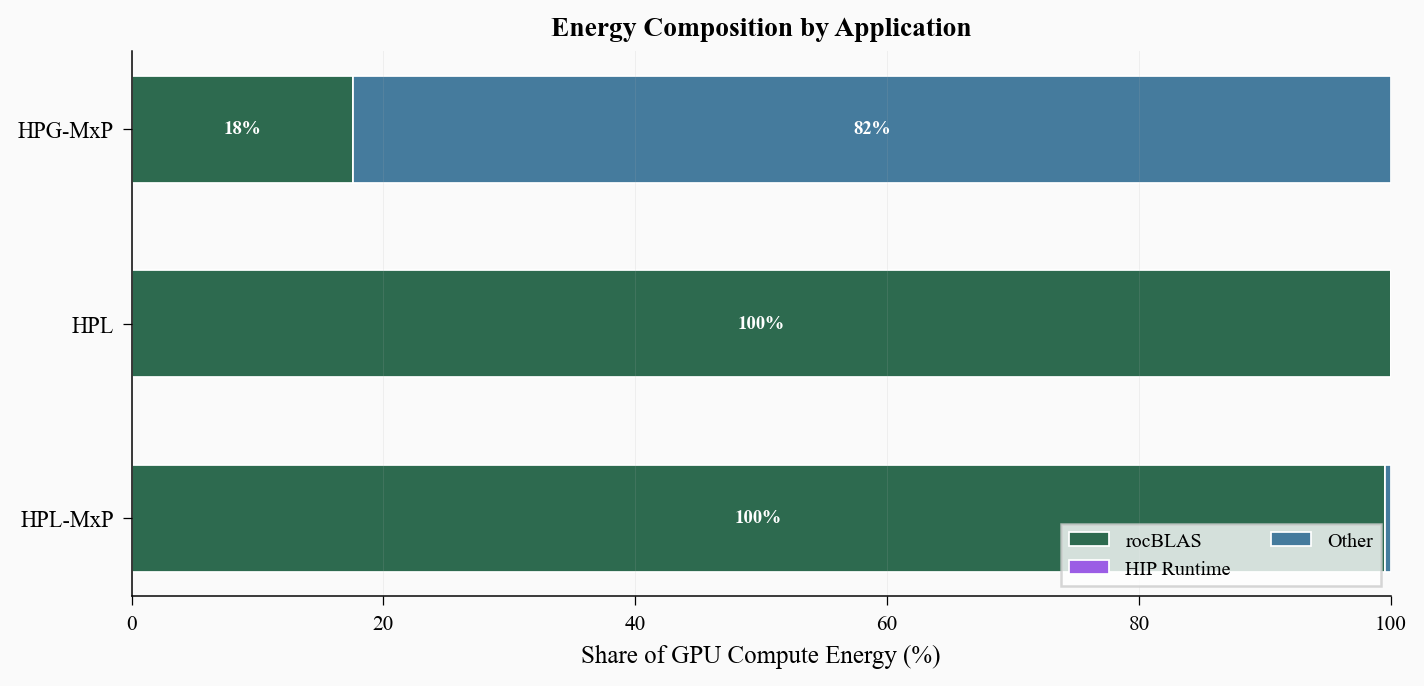

In [16]:
# -- Fig 1: Stacked bar -- library energy share per application --

pivot = (energy.groupby(['App', 'Library'])['Value']
         .sum().unstack(fill_value=0))
cols = [c for c in CAT_ORDER if c in pivot.columns]
pivot = pivot[cols]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 0.9 * len(pivot) + 1.2), facecolor=BG)
ax.set_facecolor(BG)

left = np.zeros(len(pivot_pct))
for cat in cols:
    vals = pivot_pct[cat].values
    ax.barh(np.arange(len(pivot_pct)), vals, left=left,
            color=CAT_PALETTE[cat], edgecolor='white', linewidth=0.7,
            label=cat, height=0.55)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 4:
            ax.text(l + v / 2, i, f'{v:.0f}%', ha='center', va='center',
                    fontsize=7.5, color='white' if v > 12 else '#333',
                    fontweight='bold' if v > 12 else 'normal')
    left += vals

ax.set_yticks(np.arange(len(pivot_pct)))
ax.set_yticklabels(pivot_pct.index, fontsize=9)
ax.set_xlabel('Share of GPU Compute Energy (%)')
ax.set_title('Energy Composition by Application', fontweight='bold')
ax.legend(loc='lower right', frameon=True, fancybox=False,
          edgecolor='#ccc', fontsize=8, ncol=2)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.15)

fig.tight_layout()
plt.savefig('xapp_fig1_energy_composition.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 2 -- Per-Call Power Distribution by Library Across Applications

Violin plots comparing instantaneous power draw distributions for each
library, split by application.  Reveals whether the same library is driven
at different power levels by different applications.

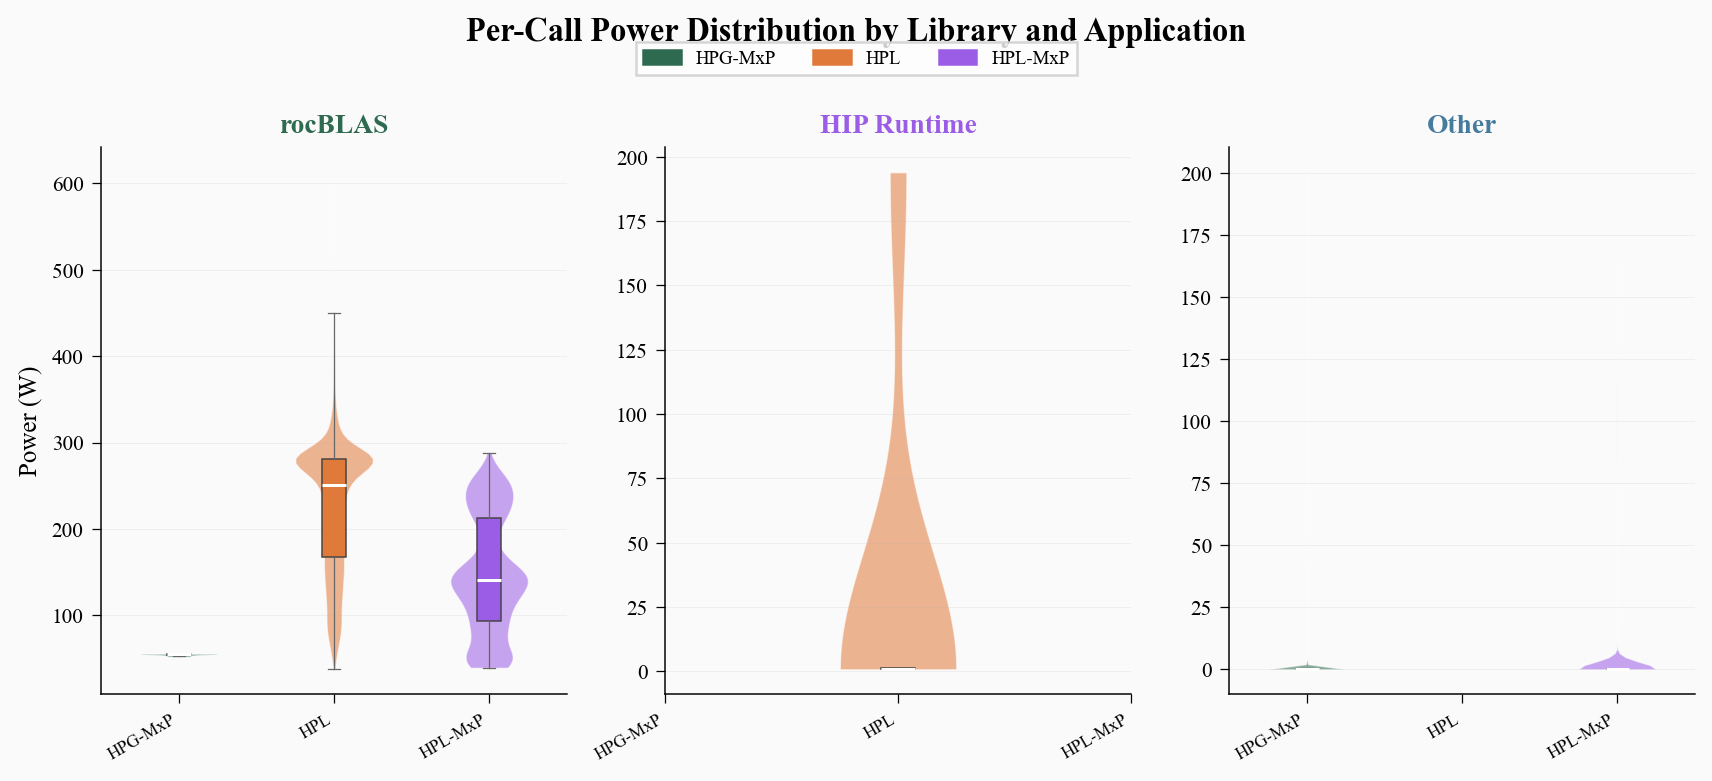

In [17]:
# -- Fig 2: Violin -- power distributions per (library, app) --

plot_cats = [c for c in CAT_ORDER if c in power_sig['Library'].unique()]
apps = sorted(power_sig['App'].unique())

fig, axes = plt.subplots(1, len(plot_cats),
                         figsize=(3.2 * len(plot_cats), 4.2),
                         sharey=False, facecolor=BG)
if len(plot_cats) == 1:
    axes = [axes]

for ax, cat in zip(axes, plot_cats):
    ax.set_facecolor(BG)
    sub = power_sig[power_sig['Library'] == cat]

    data_list, positions, colors = [], [], []
    for i, app in enumerate(apps):
        vals = sub[sub['App'] == app]['Value'].dropna().values
        if len(vals) < 3:
            continue
        data_list.append(vals)
        positions.append(i)
        colors.append(APP_PALETTE[app])

    if not data_list:
        ax.set_title(cat, fontweight='bold', color=CAT_PALETTE[cat])
        ax.text(0.5, 0.5, 'no calls', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='#999')
        continue

    parts = ax.violinplot(data_list, positions=positions,
                          showmeans=False, showextrema=False, showmedians=False)
    for pc, col in zip(parts['bodies'], colors):
        pc.set_facecolor(col)
        pc.set_edgecolor('white')
        pc.set_linewidth(0.5)
        pc.set_alpha(0.55)

    # Box overlay
    bp = ax.boxplot(data_list, positions=positions, widths=0.15,
                    patch_artist=True, showfliers=False, zorder=3)
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col)
        patch.set_edgecolor('#444')
        patch.set_linewidth(0.6)
    for el in ('whiskers', 'caps'):
        for line in bp[el]:
            line.set_color('#666')
            line.set_linewidth(0.5)
    for line in bp['medians']:
        line.set_color('white')
        line.set_linewidth(1.2)

    ax.set_xticks(range(len(apps)))
    ax.set_xticklabels(apps, rotation=30, ha='right', fontsize=7)
    ax.set_title(cat, fontweight='bold', color=CAT_PALETTE[cat])
    ax.set_ylabel('Power (W)' if ax == axes[0] else '')
    ax.grid(axis='y', alpha=0.15)

fig.suptitle('Per-Call Power Distribution by Library and Application',
             fontweight='bold', y=1.02)

handles = [mpatches.Patch(color=APP_PALETTE[a], label=a) for a in apps]
fig.legend(handles=handles, loc='upper center', ncol=len(apps),
           frameon=True, fancybox=False, edgecolor='#ccc', fontsize=7.5,
           bbox_to_anchor=(0.5, 1.0))

fig.tight_layout()
plt.savefig('xapp_fig2_power_violins.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 3 -- Energy vs. Power: Function Landscape Across All Apps

Each bubble is one function (aggregated per application).  X = mean power draw,
Y = total energy consumed, bubble size = number of invocations, colour = library.
Shape distinguishes applications.  Answers: which functions are the big energy
consumers, and is it because they draw lots of power or because they run many times?

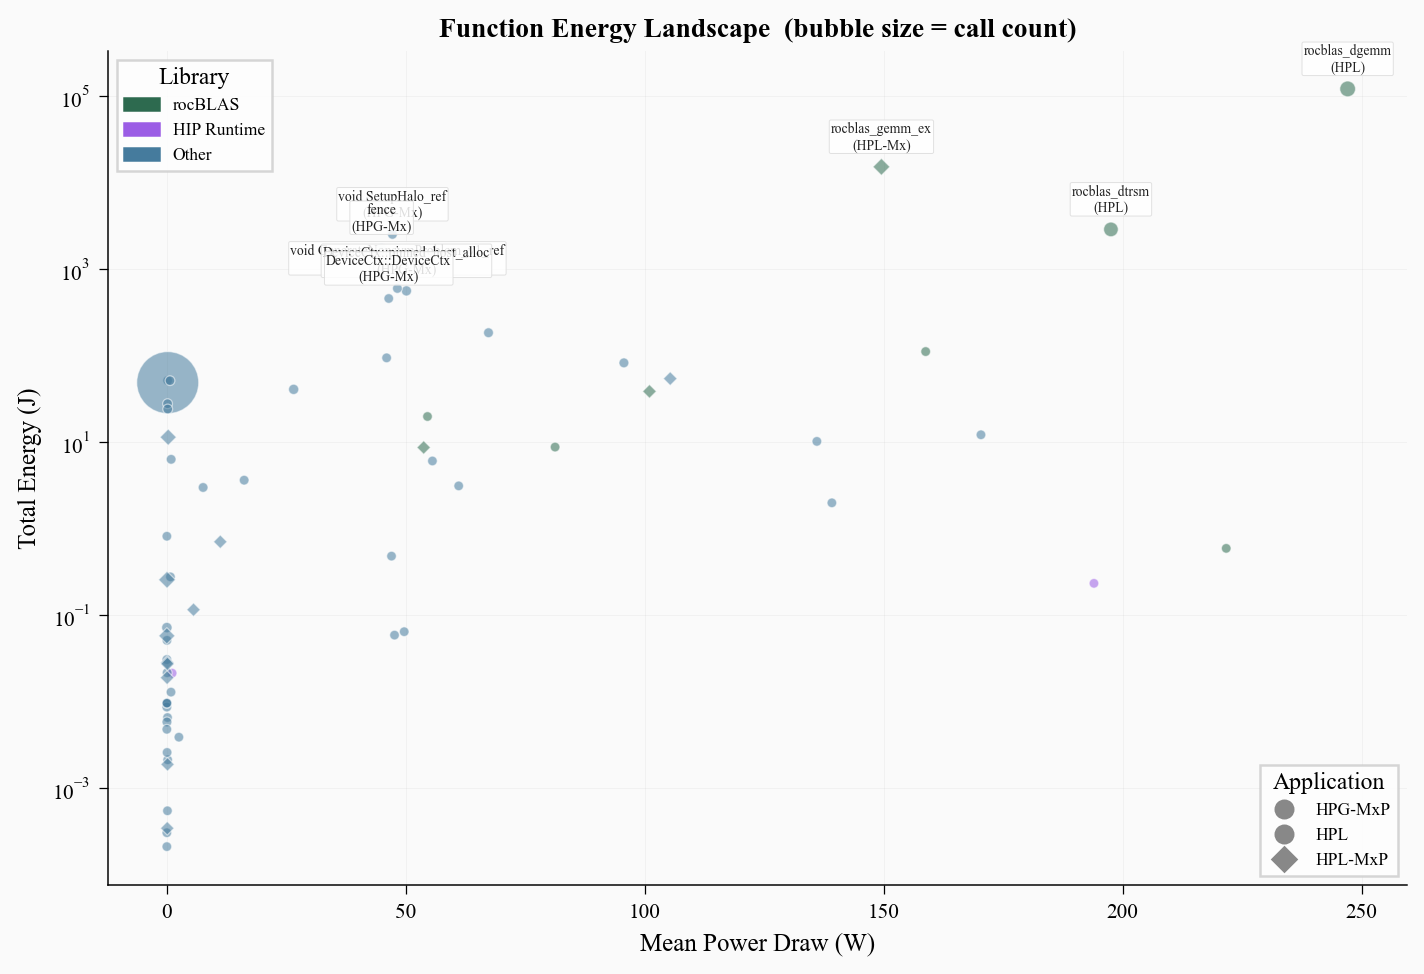

In [18]:
# -- Fig 3: Bubble -- energy vs power per function per app --

func_agg = (energy_sig.groupby(['App', 'ShortName', 'Library']).agg(
    total_energy=('Value', 'sum'),
    total_time=('Duration', 'sum'),
    n_calls=('Value', 'count'),
).reset_index())

power_agg = (power_sig.groupby(['App', 'ShortName'])['Value']
             .mean().rename('mean_power').reset_index())
func_agg = func_agg.merge(power_agg, on=['App', 'ShortName'], how='left')
func_agg = func_agg.dropna(subset=['mean_power'])
func_agg = func_agg[func_agg['total_energy'] > 0]

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=BG)
ax.set_facecolor(BG)

markers = {'HPL': 'o', 'HPL (no lib wrapping)': 's', 'HPL-MxP': 'D'}
max_calls = func_agg['n_calls'].max()

for cat in CAT_ORDER:
    for app in sorted(TRACES.keys()):
        sub = func_agg[(func_agg['Library'] == cat) & (func_agg['App'] == app)]
        if sub.empty:
            continue
        sizes = sub['n_calls'] / max_calls * 600 + 15
        ax.scatter(sub['mean_power'], sub['total_energy'], s=sizes,
                   color=CAT_PALETTE[cat], alpha=0.55,
                   edgecolors='white', linewidths=0.5,
                   marker=markers.get(app, 'o'), zorder=3)

# Label top functions
top = func_agg.nlargest(8, 'total_energy')
for _, row in top.iterrows():
    label = f"{row['ShortName']}\n({row['App'][:6]})"
    ax.annotate(label, (row['mean_power'], row['total_energy']),
                fontsize=5.5, ha='center', va='bottom',
                xytext=(0, 6), textcoords='offset points', color='#222',
                bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='#ddd',
                          alpha=0.85, linewidth=0.4))

ax.set_xlabel('Mean Power Draw (W)')
ax.set_ylabel('Total Energy (J)')
ax.set_title('Function Energy Landscape  (bubble size = call count)',
             fontweight='bold')
ax.grid(alpha=0.12)

if func_agg['total_energy'].max() / max(func_agg['total_energy'].min(), 1e-12) > 100:
    ax.set_yscale('log')

# Two legends
lib_handles = [mpatches.Patch(color=CAT_PALETTE[c], label=c) for c in CAT_ORDER
               if c in func_agg['Library'].values]
app_handles = [Line2D([0], [0], marker=markers.get(a, 'o'), color='#888',
               markerfacecolor='#888', markersize=7, linestyle='None', label=a)
               for a in sorted(TRACES.keys())]
leg1 = ax.legend(handles=lib_handles, loc='upper left', title='Library',
                 frameon=True, fancybox=False, edgecolor='#ccc', fontsize=7)
ax.add_artist(leg1)
ax.legend(handles=app_handles, loc='lower right', title='Application',
          frameon=True, fancybox=False, edgecolor='#ccc', fontsize=7)

fig.tight_layout()
plt.savefig('xapp_fig3_energy_landscape.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 4 -- Top Functions by Total Energy (Across All Apps)

Horizontal bars of the functions that consume the most GPU energy across all
applications.  Stacked by application to show shared vs. app-specific hotspots.

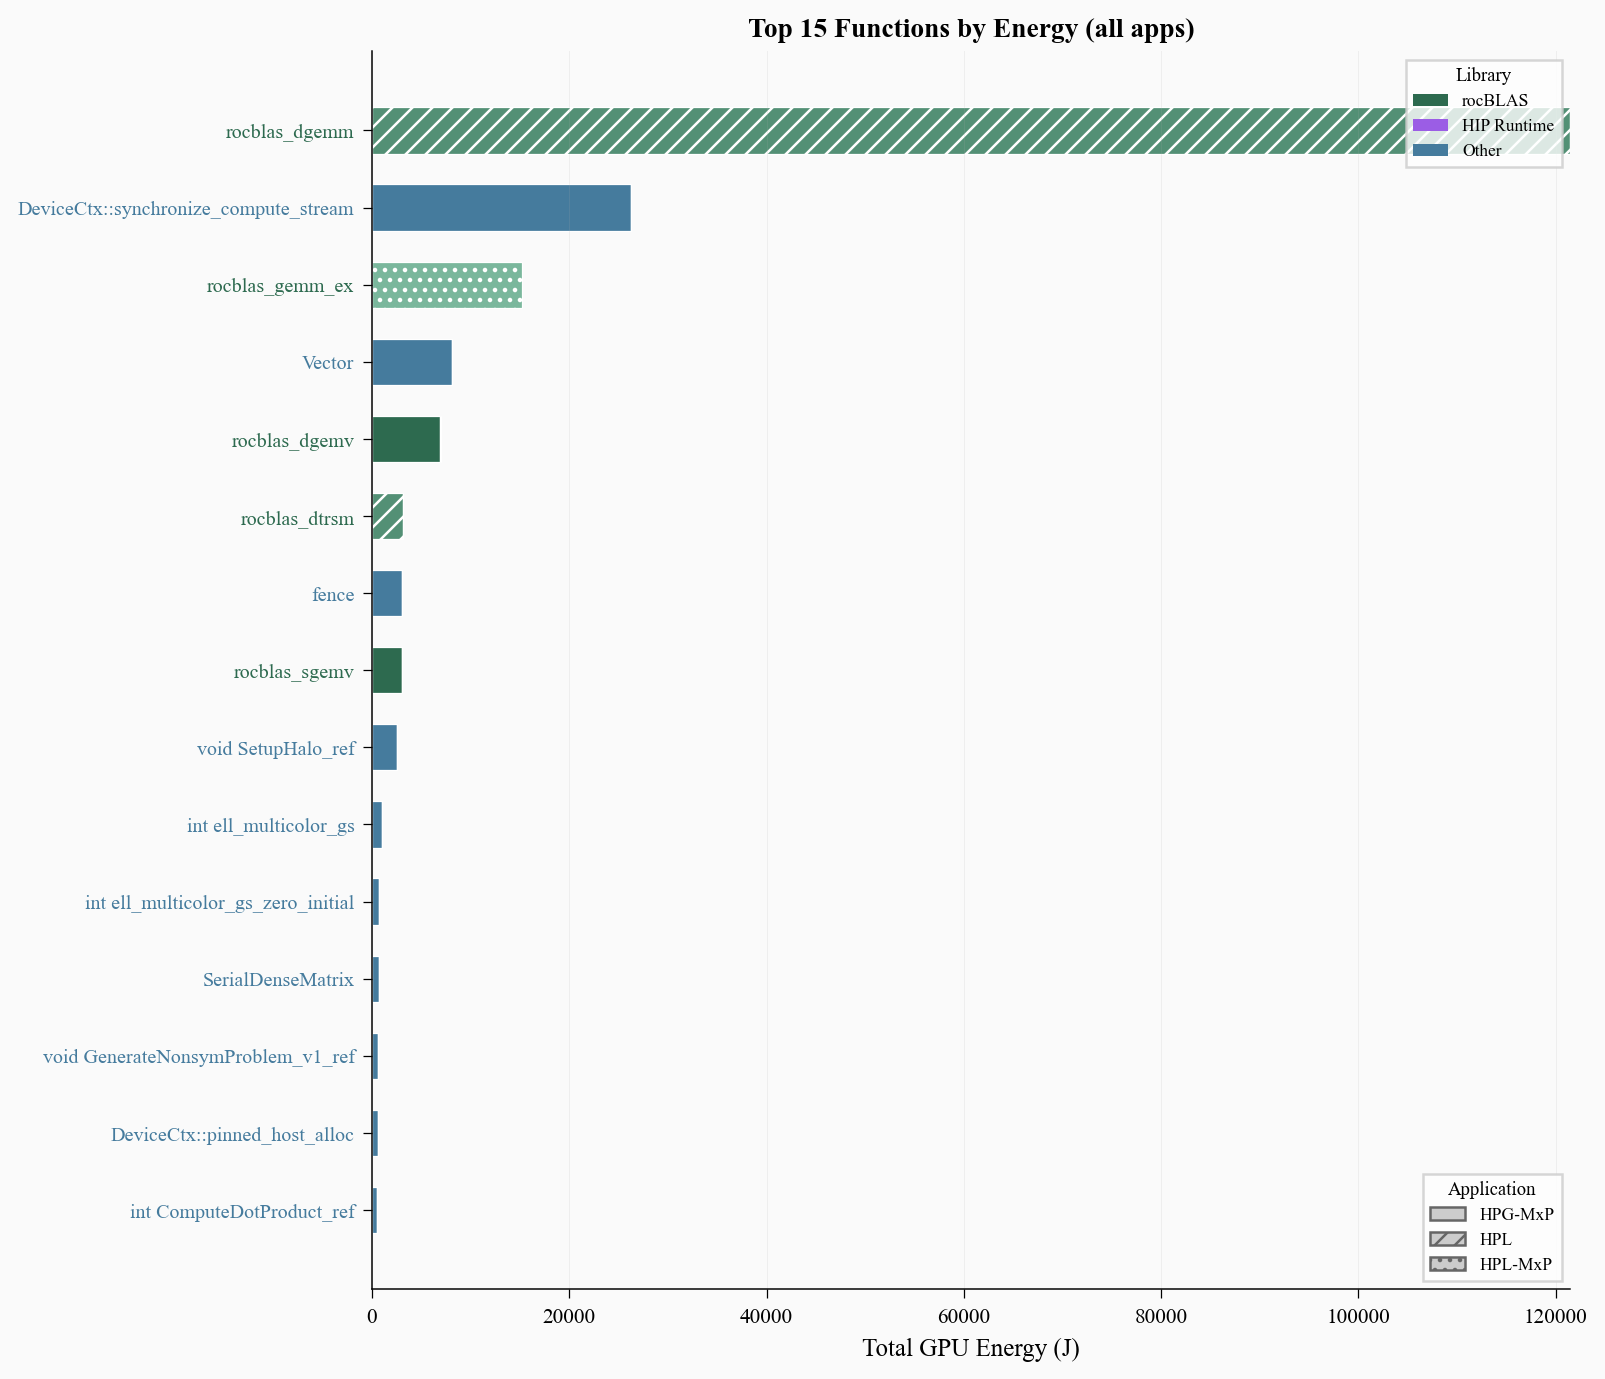

In [19]:
# -- Fig 4: Horizontal bar -- top functions by energy --

TOP_N = 15
func_total = energy.groupby('ShortName')['Value'].sum().sort_values(ascending=False)
top_funcs = func_total.head(TOP_N).index.tolist()

plot_data = (energy[energy['ShortName'].isin(top_funcs)]
             .groupby(['ShortName', 'App'])['Value'].sum()
             .unstack(fill_value=0))
plot_data['_total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values('_total', ascending=True).drop(columns='_total')

func_cat = energy.groupby('ShortName')['Library'].first().to_dict()

fig, ax = plt.subplots(figsize=(9, 0.45 * TOP_N + 1), facecolor=BG)
ax.set_facecolor(BG)

y_pos = np.arange(len(plot_data))
left = np.zeros(len(plot_data))

for j, app in enumerate(sorted(plot_data.columns)):
    vals = plot_data[app].values
    base_colors = [CAT_PALETTE.get(func_cat.get(f, 'Other'), '#888')
                   for f in plot_data.index]
    if j > 0:
        base_colors = [tuple(min(c + 0.15 * j, 1.0) for c in mcolors.to_rgb(bc))
                       for bc in base_colors]
    hatches = ['', '///', '...', 'xxx']
    ax.barh(y_pos, vals, left=left, color=base_colors,
            edgecolor='white', linewidth=0.5, height=0.6,
            hatch=hatches[j % len(hatches)], label=app)
    left += vals

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data.index, fontsize=8)
for i, f in enumerate(plot_data.index):
    ax.get_yticklabels()[i].set_color(
        CAT_PALETTE.get(func_cat.get(f, 'Other'), '#333'))

ax.set_xlabel('Total GPU Energy (J)')
ax.set_title(f'Top {TOP_N} Functions by Energy (all apps)', fontweight='bold')
ax.grid(axis='x', alpha=0.15)

app_handles = [mpatches.Patch(facecolor='#ccc', edgecolor='#666',
               hatch=hatches[j % len(hatches)], label=app)
               for j, app in enumerate(sorted(plot_data.columns))]
lib_handles = [mpatches.Patch(facecolor=CAT_PALETTE[c], label=c)
               for c in CAT_ORDER if c in func_cat.values()]
leg1 = ax.legend(handles=app_handles, loc='lower right', title='Application',
                 frameon=True, fancybox=False, edgecolor='#ccc', fontsize=7,
                 title_fontsize=7.5)
ax.add_artist(leg1)
ax.legend(handles=lib_handles, loc='upper right', title='Library',
          frameon=True, fancybox=False, edgecolor='#ccc', fontsize=7,
          title_fontsize=7.5)

fig.tight_layout()
plt.savefig('xapp_fig4_top_functions.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 5 -- Energy per Call vs. Duration: Power Efficiency

Each dot is an individual library call (subsampled for clarity).
X = call duration, Y = energy consumed, colour = library.
The slope of the cloud reveals the **effective power draw** of that library's
calls.  Calls above the main trend drew more power than average; calls below
were more energy-efficient.  Diagonal reference lines show constant-power contours.

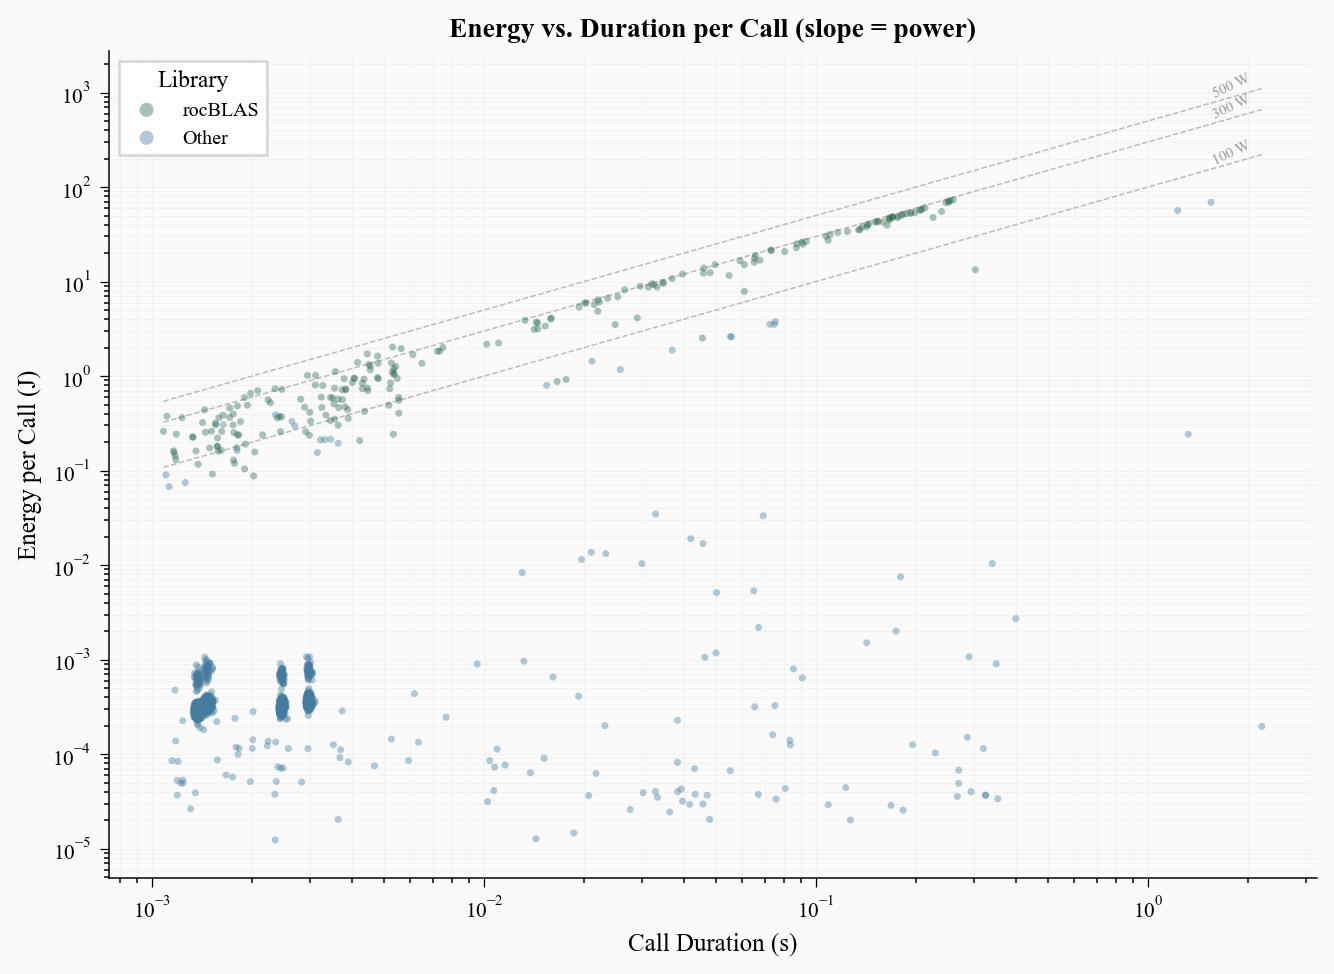

In [20]:
# -- Fig 5: Scatter -- energy per call vs duration --

sig = energy_sig[energy_sig['Value'] > 0].copy()

# Subsample for clarity
MAX_PTS = 3000
if len(sig) > MAX_PTS:
    sig_plot = sig.sample(MAX_PTS, random_state=42)
else:
    sig_plot = sig

fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor=BG)
ax.set_facecolor(BG)

for cat in CAT_ORDER:
    sub = sig_plot[sig_plot['Library'] == cat]
    if sub.empty:
        continue
    ax.scatter(sub['Duration'], sub['Value'], s=8, alpha=0.4,
               color=CAT_PALETTE[cat], edgecolors='none',
               label=cat, rasterized=True, zorder=3)

# Constant-power reference lines (P = E / t)
dur_range = np.array([sig_plot['Duration'].min(), sig_plot['Duration'].max()])
for pw, label in [(100, '100 W'), (300, '300 W'), (500, '500 W')]:
    ax.plot(dur_range, pw * dur_range, '--', color='#bbb', linewidth=0.6, zorder=1)
    ax.text(dur_range[-1] * 0.7, pw * dur_range[-1] * 0.7 * 1.15,
            label, fontsize=6, color='#999', rotation=25)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Call Duration (s)')
ax.set_ylabel('Energy per Call (J)')
ax.set_title('Energy vs. Duration per Call (slope = power)',
             fontweight='bold')
ax.legend(title='Library', frameon=True, fancybox=False, edgecolor='#ccc',
          fontsize=8, markerscale=2)
ax.grid(alpha=0.1, which='both')

fig.tight_layout()
plt.savefig('xapp_fig5_energy_vs_duration.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 6 -- Power ECDF by Library

Empirical cumulative distribution of per-call power draw, split by library
and pooled across all applications.  Shows what fraction of calls operate
above/below any given power threshold.

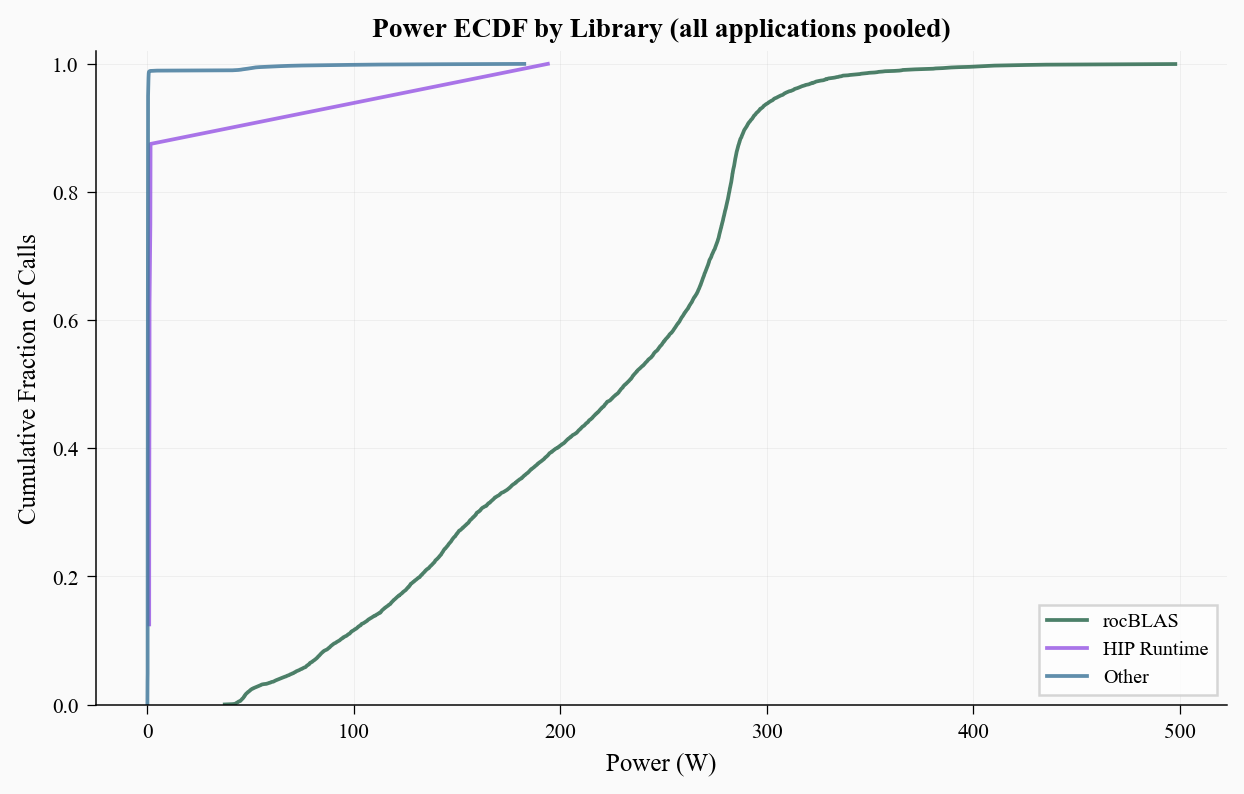

In [21]:
# -- Fig 6: ECDF -- power by library --

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=BG)
ax.set_facecolor(BG)

for cat in CAT_ORDER:
    vals = power_sig[power_sig['Library'] == cat]['Value'].dropna().values
    if len(vals) < 2:
        continue
    sorted_vals = np.sort(vals)
    ecdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    step = max(1, len(sorted_vals) // 2000)
    ax.plot(sorted_vals[::step], ecdf[::step],
            color=CAT_PALETTE[cat], linewidth=1.5, label=cat, alpha=0.85)

ax.set_xlabel('Power (W)')
ax.set_ylabel('Cumulative Fraction of Calls')
ax.set_title('Power ECDF by Library (all applications pooled)',
             fontweight='bold')
ax.legend(frameon=True, fancybox=False, edgecolor='#ccc', fontsize=8)
ax.grid(alpha=0.15)
ax.set_ylim(0, 1.02)

fig.tight_layout()
plt.savefig('xapp_fig6_power_ecdf.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 7 -- Paired Lollipop: Energy Share vs. Time Share by Library

For each library, compare its share of total **energy** against its share of
total **time** (duration).  Libraries where the energy dot is to the right of
the time dot draw disproportionately more power during their execution.

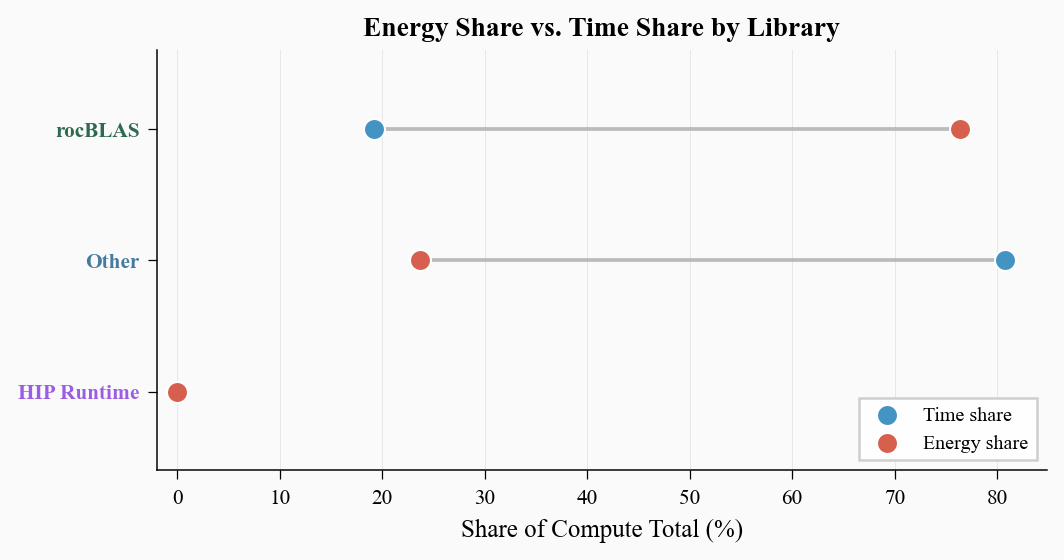

In [22]:
# -- Fig 7: Paired lollipop -- energy share vs time share --

e_by_lib = energy.groupby('Library')['Value'].sum()
e_frac = (e_by_lib / e_by_lib.sum() * 100)

t_by_lib = energy.groupby('Library')['Duration'].sum()
t_frac = (t_by_lib / t_by_lib.sum() * 100)

order = e_frac.sort_values(ascending=True).index.tolist()
e_frac = e_frac.reindex(order, fill_value=0)
t_frac = t_frac.reindex(order, fill_value=0)
y_pos = np.arange(len(order))

fig, ax = plt.subplots(figsize=(6, 3.2), facecolor=BG)
ax.set_facecolor(BG)

for i, lib in enumerate(order):
    ax.plot([t_frac[lib], e_frac[lib]], [i, i],
            color='#bbbbbb', linewidth=1.5, zorder=1, solid_capstyle='round')

ax.scatter(t_frac.values, y_pos, s=70, color='#4393c3', zorder=3,
           edgecolors='white', linewidths=0.8, label='Time share')
ax.scatter(e_frac.values, y_pos, s=70, color='#d6604d', zorder=3,
           edgecolors='white', linewidths=0.8, label='Energy share')

ax.set_yticks(y_pos)
ax.set_yticklabels(order)
for i, lib in enumerate(order):
    ax.get_yticklabels()[i].set_color(CAT_PALETTE.get(lib, '#333'))
    ax.get_yticklabels()[i].set_fontweight('semibold')

ax.set_xlabel('Share of Compute Total (%)')
ax.set_title('Energy Share vs. Time Share by Library', fontweight='bold')
ax.legend(loc='lower right', frameon=True, fancybox=False,
          edgecolor='#ccc', framealpha=0.95, fontsize=8)
ax.grid(axis='x', alpha=0.25)
ax.set_xlim(left=-2)
ax.set_ylim(-0.6, len(order) - 0.4)

fig.tight_layout()
plt.savefig('xapp_fig7_energy_vs_time.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 8 -- Energy Variability: CV of Per-Call Energy by Function

The coefficient of variation (std/mean) of per-call **energy** for functions
with at least 20 invocations.  High CV means the function's energy cost is
unpredictable across calls — a challenge for energy modelling and scheduling.

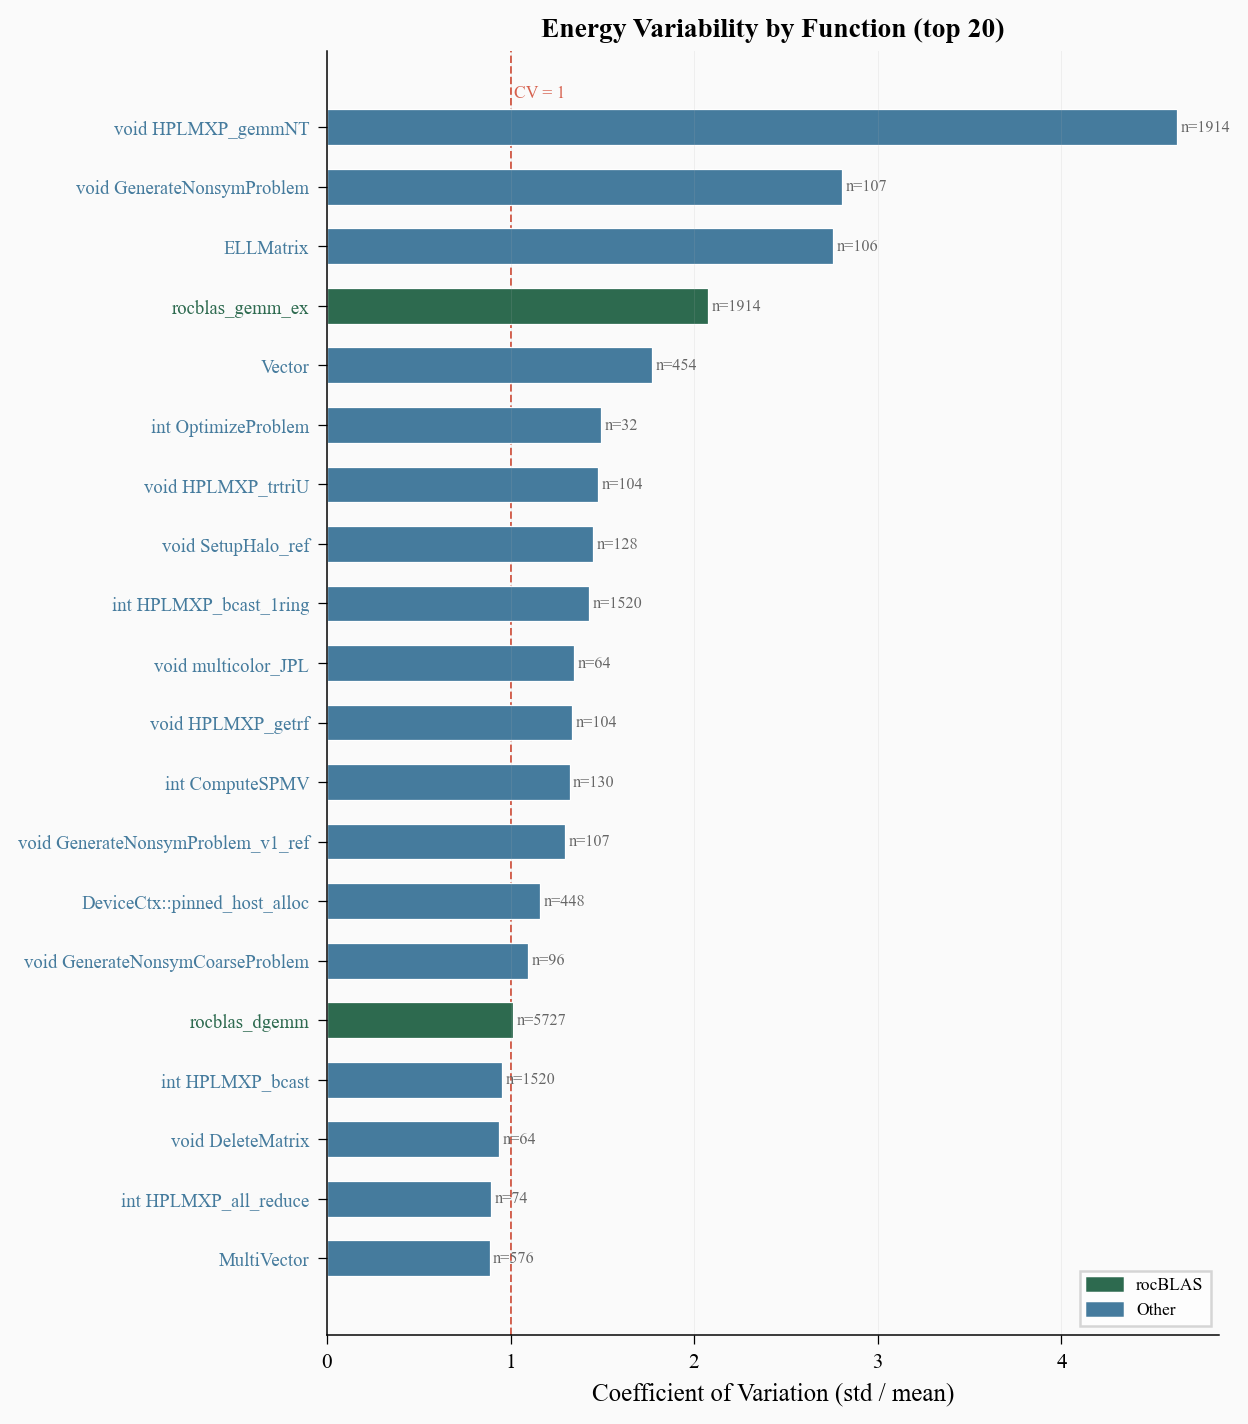

In [23]:
# -- Fig 8: CV of per-call energy --

cv_data = (energy_sig[energy_sig['Value'] > 0]
           .groupby(['ShortName', 'Library'])['Value']
           .agg(['mean', 'std', 'count']).reset_index())
cv_data = cv_data[cv_data['count'] >= 20]
cv_data['cv'] = cv_data['std'] / cv_data['mean']

top_cv = cv_data.nlargest(20, 'cv').sort_values('cv', ascending=True)

fig, ax = plt.subplots(figsize=(7, 0.35 * len(top_cv) + 1), facecolor=BG)
ax.set_facecolor(BG)

y = np.arange(len(top_cv))
colors = [CAT_PALETTE.get(cat, '#888') for cat in top_cv['Library']]

ax.barh(y, top_cv['cv'], height=0.6, color=colors, edgecolor='white', linewidth=0.5)

for i, (_, row) in enumerate(top_cv.iterrows()):
    ax.text(row['cv'] + 0.02, i, f"n={int(row['count'])}", va='center',
            fontsize=6.5, color='#666')

ax.set_yticks(y)
ax.set_yticklabels(top_cv['ShortName'], fontsize=7.5)
for i, cat in enumerate(top_cv['Library']):
    ax.get_yticklabels()[i].set_color(CAT_PALETTE.get(cat, '#333'))

ax.set_xlabel('Coefficient of Variation (std / mean)')
ax.set_title('Energy Variability by Function (top 20)', fontweight='bold')
ax.axvline(1.0, color='#d6604d', linewidth=0.8, linestyle='--', zorder=0)
ax.text(1.02, len(top_cv) - 0.5, 'CV = 1', fontsize=7, color='#d6604d')
ax.grid(axis='x', alpha=0.15)

handles = [mpatches.Patch(color=CAT_PALETTE[c], label=c) for c in CAT_ORDER
           if c in top_cv['Library'].values]
ax.legend(handles=handles, loc='lower right', frameon=True, fancybox=False,
          edgecolor='#ccc', fontsize=7)

fig.tight_layout()
plt.savefig('xapp_fig8_energy_cv.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 9 -- Ridgeline: Per-Call Energy Distributions for Top Functions

Overlapping density plots for the highest-energy functions across all
applications.  Shape and spread reveal whether a function has consistent
or highly variable energy cost.

/var/folders/tw/01tr8b7x7qx2w8074rmfk1qc0000gp/T/ipykernel_1766/2299659035.py:33: RuntimeWarning: invalid value encountered in divide
  density = density / density.max()
/var/folders/tw/01tr8b7x7qx2w8074rmfk1qc0000gp/T/ipykernel_1766/2299659035.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


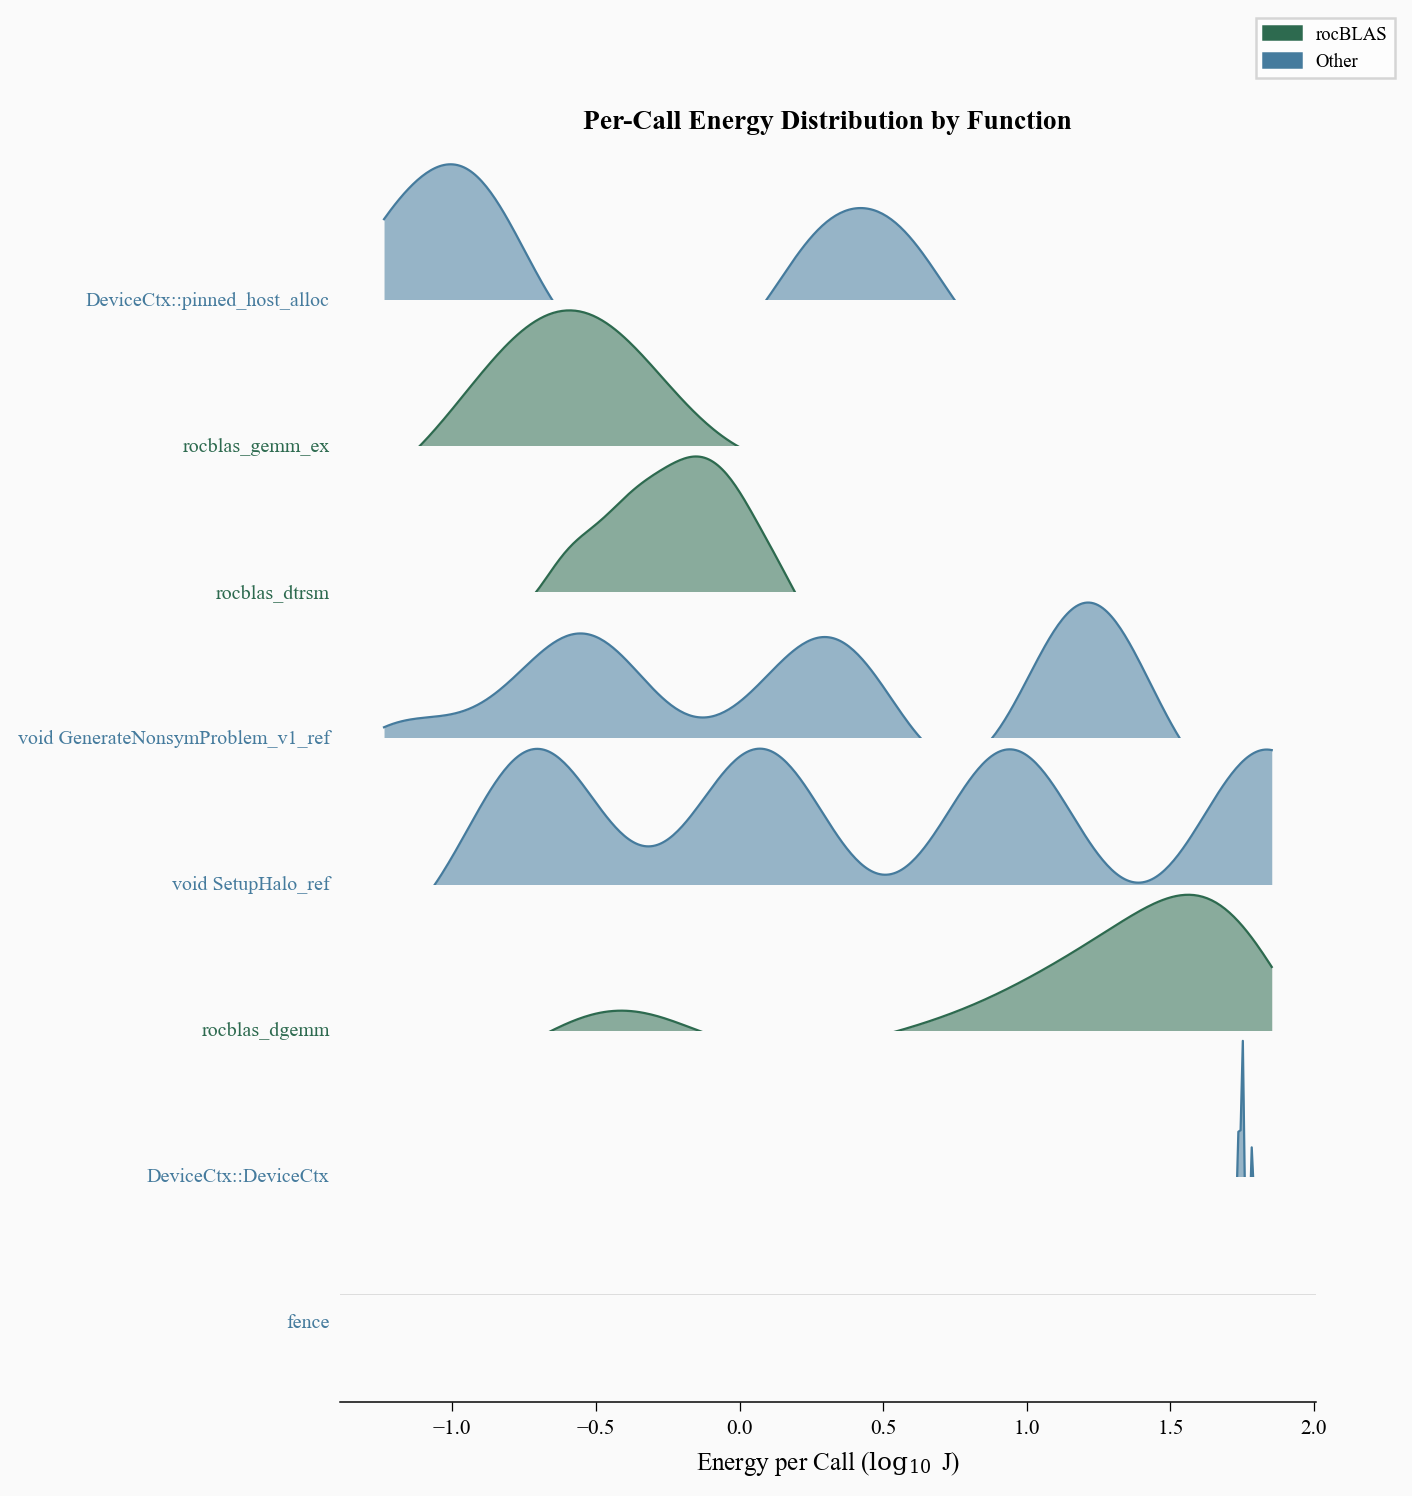

In [24]:
# -- Fig 9: Ridgeline -- energy distribution per function --

top_funcs_e = (energy_sig[energy_sig['Value'] > 0]
               .groupby('ShortName')['Value'].sum()
               .sort_values(ascending=False).head(8).index.tolist())

ridge = energy_sig[(energy_sig['ShortName'].isin(top_funcs_e)) &
                   (energy_sig['Value'] > 0)].copy()
ridge['log_energy'] = np.log10(ridge['Value'])

func_order = (ridge.groupby('ShortName')['log_energy']
              .median().reindex(top_funcs_e).sort_values(ascending=True).index.tolist())

n_funcs = len(func_order)
fig, axes = plt.subplots(n_funcs, 1, figsize=(7, 1.05 * n_funcs + 0.6),
                         sharex=True, gridspec_kw={'hspace': -0.35},
                         facecolor=BG)

all_le = ridge['log_energy'].dropna()
x_grid = np.linspace(all_le.quantile(0.005), all_le.quantile(0.995), 400)

for i, func in enumerate(func_order):
    ax = axes[i]
    ax.set_facecolor(BG)
    vals = ridge[ridge['ShortName'] == func]['log_energy'].dropna().values
    lib = ridge[ridge['ShortName'] == func]['Library'].iloc[0]
    color = CAT_PALETTE.get(lib, '#888')

    if len(vals) > 5:
        try:
            kde = gaussian_kde(vals, bw_method=0.25)
            density = kde(x_grid)
            density = density / density.max()
        except Exception:
            density = np.zeros_like(x_grid)
    else:
        density = np.zeros_like(x_grid)

    ax.fill_between(x_grid, density, alpha=0.55, color=color, linewidth=0)
    ax.plot(x_grid, density, color=color, linewidth=0.9)
    ax.axhline(0, color='#ddd', linewidth=0.4)
    ax.set_yticks([])
    ax.set_ylim(bottom=-0.05)
    ax.text(-0.01, 0.35, func, transform=ax.transAxes, ha='right', va='center',
            fontsize=8, fontweight='medium', color=color)
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[-1].set_xlabel(r'Energy per Call ($\log_{10}$ J)')
axes[-1].spines['bottom'].set_visible(True)
axes[0].set_title('Per-Call Energy Distribution by Function', fontweight='bold', pad=10)

handles = [mpatches.Patch(color=CAT_PALETTE[l], label=l)
           for l in CAT_ORDER if l in ridge['Library'].values]
fig.legend(handles=handles, loc='upper right', frameon=True,
           fancybox=False, edgecolor='#ccc', fontsize=7.5,
           bbox_to_anchor=(0.97, 0.97))

fig.tight_layout()
plt.savefig('xapp_fig9_ridgeline_energy.pdf', bbox_inches='tight', facecolor=BG)
plt.show()